# Nowcast p_3h per hex — real detections & wind, fake population

Combines real `data/processed/eaton/detections.jsonl` and `wind.jsonl` with the fake
residents, facilities, vehicles, shelters and evac_orders from `data/fixtures/eaton_fake/`.
Runs `engines.nowcast.nowcast` at three clock times (22:00, 01:00, 03:25 PST) and plots
the per-cell p_3h heat-map for each.

In [1]:
import json
import shutil
import tempfile
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import h3
import matplotlib.pyplot as plt

from backend.store import DataStore
from engines.nowcast import nowcast

PACIFIC = ZoneInfo("America/Los_Angeles")
REPO = Path("..").resolve()

FAKE_DIR = REPO / "data" / "fixtures" / "eaton_fake"
REAL_DIR = REPO / "data" / "processed" / "eaton"

FAKE_FILES = ["residents.jsonl", "facilities.jsonl", "vehicles.jsonl",
              "shelters.jsonl", "evac_orders.jsonl"]
REAL_FILES = ["detections.jsonl", "wind.jsonl"]

META = {
    "name": "eaton_merged_notebook",
    "synthetic": False,
    "description": "Real detections + wind; fake population. Notebook only.",
    "bbox": {"south": 34.16, "west": -118.18, "north": 34.215, "east": -118.08},
    "h3_res": 9,
    "replay": {
        "start": "2025-01-07T18:00:00-08:00",
        "end":   "2025-01-08T06:00:00-08:00",
        "step_minutes": 10,
    },
}

TIMES = [
    datetime(2025, 1, 7, 22,  0, tzinfo=PACIFIC),   # 22:00 PST  (fire ~3.5 h old, pre-VIIRS)
    datetime(2025, 1, 8,  1,  0, tzinfo=PACIFIC),   # 01:00 PST  (VIIRS first overpass)
    datetime(2025, 1, 8,  3, 25, tzinfo=PACIFIC),   # 03:25 PST  (west-Altadena evac order)
]
LABELS = ["22:00 PST", "01:00 PST", "03:25 PST"]

In [2]:
# Build temp dataset, run nowcast, clean up temp dir — all in one cell so the
# try/finally never straddles a cell boundary.

tmp = Path(tempfile.mkdtemp(prefix="outrun_nowcast_"))
results: list[dict[str, float]] = []
cells_ref: list[str] = []

try:
    (tmp / "meta.json").write_text(json.dumps(META, indent=2))
    for fname in FAKE_FILES:
        shutil.copy(FAKE_DIR / fname, tmp / fname)
    for fname in REAL_FILES:
        shutil.copy(REAL_DIR / fname, tmp / fname)

    store = DataStore(tmp)
    first_available = min(d.available_at for d in store.detections)
    print("first detection available at",
          first_available.astimezone(PACIFIC).strftime("%H:%M PST"))
    cells_ref = store.cells

    for t in TIMES:
        snap = store.at(t)
        out = nowcast(snap.detections, snap.wind, store.cells, t, snap.reports)
        results.append({o.h3: o.p_3h for o in out})
        print(f"{t.strftime('%H:%M PST')}  visible_dets={len(snap.detections):3d}  "
              f"outlook_cells={len(out):4d}")
finally:
    shutil.rmtree(tmp, ignore_errors=True)

first detection available at 01:32 PST
22:00 PST  visible_dets=  0  outlook_cells=   0
01:00 PST  visible_dets=  0  outlook_cells=   0


03:25 PST  visible_dets=635  outlook_cells= 470


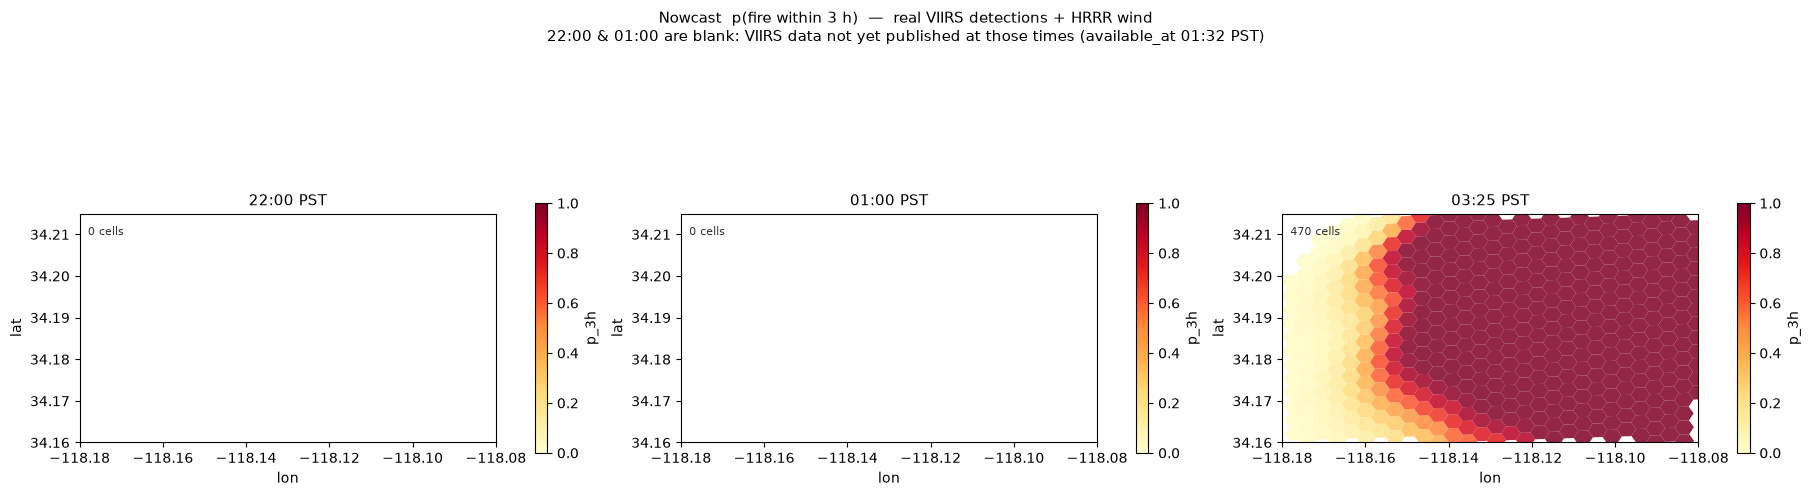

In [3]:
# Plot: three subplots, one per time, hexes coloured by p_3h.
# Times before first_available will be empty (no hindsight).

bbox = META["bbox"]
s, w, n, e = bbox["south"], bbox["west"], bbox["north"], bbox["east"]
cmap = plt.cm.YlOrRd

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
fig.suptitle(
    "Nowcast  p(fire within 3 h)  —  real VIIRS detections + HRRR wind\n"
    f"22:00 & 01:00 are blank: VIIRS data not yet published at those times "
    f"(available_at {first_available.astimezone(PACIFIC).strftime('%H:%M PST')})",
    fontsize=11,
)

for ax, label, p3h_map in zip(axes, LABELS, results, strict=True):
    ax.set_xlim(w, e)
    ax.set_ylim(s, n)
    ax.set_aspect("equal")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

    for cell, p3h in p3h_map.items():
        boundary = h3.cell_to_boundary(cell)   # [(lat, lon), ...]
        xs = [lon for lat, lon in boundary] + [boundary[0][1]]
        ys = [lat for lat, lon in boundary] + [boundary[0][0]]
        ax.fill(xs, ys, color=cmap(p3h), alpha=0.85, linewidth=0)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, label="p_3h")
    ax.text(w + 0.002, n - 0.003, f"{len(p3h_map)} cells",
            fontsize=8, va="top", color="#333333")

plt.show()